### Attempt to create synthetic data

In [4]:
from pathlib import Path
import pandas as pd

# -----------------------------
# User inputs
# -----------------------------
data_dir = Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/fixed/jatafixed/merged")
file_pattern = "*.csv"


# -----------------------------
# Compile filtered data
# -----------------------------
compiled_dfs = []

for file in data_dir.glob(file_pattern):
    df = pd.read_csv(file)
    df["source_file"] = file.name

    compiled_dfs.append(df)

if compiled_dfs:
    compiled_df = pd.concat(compiled_dfs, ignore_index=True)
else:
    compiled_df = pd.DataFrame()

print(f"Compiled dataframe shape: {compiled_df.shape}")

Compiled dataframe shape: (125576, 14)


In [5]:
compiled_df.head()


,trigger#,RoiNumber,PMTB,ADCtime,RunTime,InhibitTime,InhibitTimeDiff,VolumeAnalyzed,RoiType,RoiHeight,RoiWidth,RoiX,RoiY,source_file
0,2,2,0.053962,13.930572,13.953166,0.073581,0.073581,0.057832,1,44,72,924,366,D20260603T192533_IFCB124_adc_only.csv
1,3,3,0.005478,14.111737,14.134870,0.160532,0.086951,0.058226,1,44,72,932,158,D20260603T192533_IFCB124_adc_only.csv
2,4,4,0.008956,14.292811,14.315775,0.245254,0.084722,0.058627,1,116,144,844,678,D20260603T192533_IFCB124_adc_only.csv
3,5,5,0.005080,14.384296,14.406997,0.331393,0.086139,0.058648,1,52,72,924,582,D20260603T192533_IFCB124_adc_only.csv
4,6,6,0.010838,14.482679,14.506007,0.420647,0.089253,0.058689,1,52,72,948,302,D20260603T192533_IFCB124_adc_only.csv


(array([2421., 2582., 2551., 2532., 2558., 2550., 2540., 2562., 2541.,
        2552., 2519., 2560., 2498., 2550., 2551., 2545., 2528., 2545.,
        2538., 2571., 2544., 2522., 2499., 2546., 2662., 2539., 2614.,
        2605., 2585., 2603., 2558., 2558., 2568., 2581., 2638., 2571.,
        2593., 2596., 2549., 2548., 2473., 2521., 2469., 2481., 2423.,
        2358., 2316., 2171., 2093., 1998.]),
 array([  13.4725217 ,   37.24573793,   61.01895417,   84.7921704 ,
         108.56538663,  132.33860286,  156.1118191 ,  179.88503533,
         203.65825156,  227.4314678 ,  251.20468403,  274.97790026,
         298.75111649,  322.52433273,  346.29754896,  370.07076519,
         393.84398142,  417.61719766,  441.39041389,  465.16363012,
         488.93684635,  512.71006259,  536.48327882,  560.25649505,
         584.02971128,  607.80292752,  631.57614375,  655.34935998,
         679.12257622,  702.89579245,  726.66900868,  750.44222491,
         774.21544115,  797.98865738,  821.76187361,  84

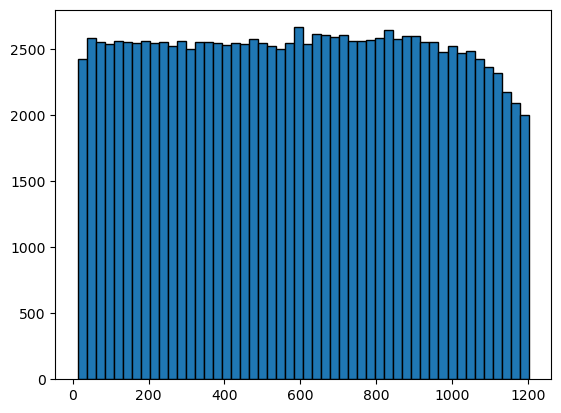

In [7]:
from matplotlib import pyplot as plt
plt.hist(compiled_df["RunTime"], bins=50, edgecolor='black')

In [43]:

compiled_df.sort_values("RunTime").head(n=25)
#compiled_df.shape[0]
compiled_df["InhibitTimeDiff"].median()

np.float64(0.0857638888888914)

In [22]:
sort_df = compiled_df.sort_values("RunTime")
sort_df["delta"] = sort_df["RunTime"].diff()
sort_df[["RunTime", "delta"]].head(n=25)

,RunTime,delta
90107,13.472522,NaN
80735,13.733563,0.261042
110266,13.784143,0.050579
14392,13.786649,0.002507
34581,13.790573,0.003924
96362,13.809510,0.018937
23475,13.833121,0.023611
105011,13.835317,0.002196
19080,13.838138,0.002821
121752,13.852849,0.014711


(0.0, 0.2)

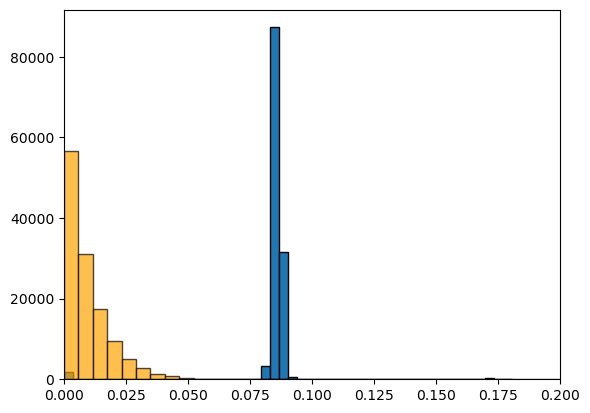

In [46]:
plt.hist(sort_df[sort_df["InhibitTimeDiff"] < 0.2]["InhibitTimeDiff"], bins=50, edgecolor='black')
plt.hist(sort_df["delta"], bins=50, edgecolor='black', color='orange', alpha=0.7)
plt.xlim(0, 0.2)

In [27]:
## Are deltas the same as inhibit times
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(sort_df["delta"].dropna(), sort_df["InhibitTimeDiff"].dropna(), equal_var=False)
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")

T-statistic: -23.5650, P-value: 0.0000


## Simple approach probably stupid but will likely learn somethibg
#### instead of using real data what if we make a function that
1. a function to build the distribution of underlying true particles. A good start would be just a uniform distribution across time from 0-1200 with a user defined concentration 
 2. a function samples from these randomly such that inhibit time is inforced and final average FPS is some user defined value
 3. Creates new dataframe of these values and calculates the concentration estimate 
 4. calculates the volume analyzed = 1200 - (number rois * inhibit time)/240
## I am interested in the relationships between FPS Volume analayzed and total rois captured and concentration estimate


In [ ]:
## Simulate poisson process with uniform arrival times

import numpy as np

def simulate_uniform_particles(
    mean_particles, ## Mean number of particles in the whole 5ml syringe
    run_duration=1200, ## Time in seconds 
    seed=None
):
    rng = np.random.default_rng(seed)

    n_particles = rng.poisson(mean_particles)

    arrival_times = np.sort(
        rng.uniform(0, run_duration, n_particles)
    )

    return arrival_times

In [35]:
times = simulate_uniform_particles(
    mean_particles=25000
)

In [ ]:
import numpy as np
import pandas as pd

def simulate_ifcb_sampling(arrival_times, inhibit_time=0.08):
    """
    Simulate IFCB sampling with a fixed inhibit time after each accepted trigger.

    Parameters
    ----------
    arrival_times : array-like
        Sorted or unsorted underlying particle arrival times in seconds.
    inhibit_time : float
        Time after each accepted trigger during which new particles cannot be sampled.

    Returns
    -------
    sampled_df : pandas.DataFrame
        DataFrame containing accepted particle arrival times.
    rejected_df : pandas.DataFrame
        DataFrame containing rejected particle arrival times.
    """

    arrival_times = np.sort(np.asarray(arrival_times))

    sampled_flags = []
    next_available_time = 0

    for t in arrival_times:
        if t >= next_available_time:
            sampled_flags.append(True)
            next_available_time = t + inhibit_time
        else:
            sampled_flags.append(False)

    df = pd.DataFrame({
        "arrival_time": arrival_times,
        "sampled": sampled_flags
          })

    return df

In [52]:
ifcb_df = simulate_ifcb_sampling(times)
sampled = ifcb_df[ifcb_df["sampled"]]
rejected = ifcb_df[~ifcb_df["sampled"]]

In [57]:
ifcb_df.head()

,arrival_time,sampled
0,0.038534,True
1,0.144660,True
2,0.242695,True
3,0.252686,False
4,0.343154,True


In [61]:
underlying_particles = len(ifcb_df)
sampled_particles = int(ifcb_df["sampled"].sum())
rejected_particles = int((~ifcb_df["sampled"]).sum())
Volume_analyzed = (1200 -sampled_particles * 0.08) / 240
FPS = sampled_particles / 1200
conc_estimate = sampled_particles / Volume_analyzed

summary = {
    "underlying_particles": underlying_particles,
    "sampled_particles": sampled_particles,
    "rejected_particles": rejected_particles,
    "Volume_analyzed": Volume_analyzed,
    "FPS": FPS,
    "Concentration_estimate": conc_estimate
}

summary 

{'underlying_particles': 25006,
 'sampled_particles': 9414,
 'rejected_particles': 15592,
 'Volume_analyzed': 1.8619999999999999,
 'FPS': 7.845,
 'Concentration_estimate': 5055.853920515575}

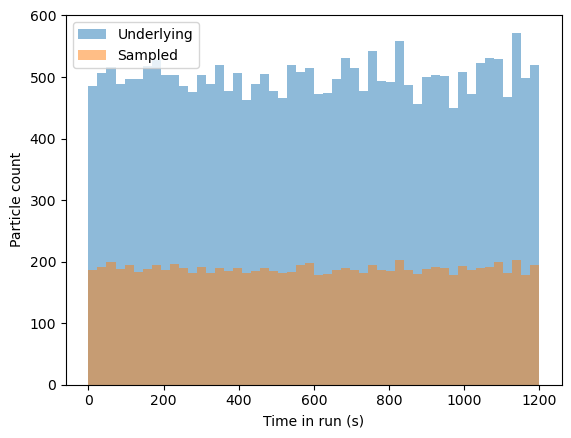

In [54]:
plt.hist(ifcb_df["arrival_time"], bins=50, alpha=0.5, label="Underlying")
plt.hist(sampled["arrival_time"], bins=50, alpha=0.5, label="Sampled")
plt.xlabel("Time in run (s)")
plt.ylabel("Particle count")
plt.legend()
plt.show()

## Using this model now lets just look at a variety of concentratios and see what the effect is on estimation and fps and volume analyzed

In [66]:
import pandas as pd

particles = [1000, 5000, 10000, 25000, 50000, 75000, 100000, 125000, 150000, 175000, 200000]

summary_rows = []

for p in particles:

    times = simulate_uniform_particles(mean_particles=p)

    ifcb_df = simulate_ifcb_sampling(
        times,
        inhibit_time=0.08
    )

    underlying_particles = len(ifcb_df)
    sampled_particles = int(ifcb_df["sampled"].sum())
    rejected_particles = int((~ifcb_df["sampled"]).sum())

    Volume_analyzed = (1200 - sampled_particles * 0.08) / 240
    FPS = sampled_particles / 1200
    conc_estimate = sampled_particles / Volume_analyzed

    summary_rows.append({
        "target_particles": p,
        "underlying_particles": underlying_particles,
        "sampled_particles": sampled_particles,
        "rejected_particles": rejected_particles,
        "Volume_analyzed": Volume_analyzed,
        "FPS": FPS,
        "Target_concentration": p / 5, ## Assuming 5ml syringe
        "Concentration_estimate": conc_estimate
    })

summary_df = pd.DataFrame(summary_rows)

print(summary_df)

    target_particles  underlying_particles  sampled_particles  \
0               1000                   970                908   
1               5000                  4832               3672   
2              10000                  9962               5960   
3              25000                 24743               9332   
4              50000                 49897              11531   
5              75000                 75207              12478   
6             100000                 99854              13057   
7             125000                125365              13400   
8             150000                150228              13640   
9             175000                175382              13811   
10            200000                199587              13951   

    rejected_particles  Volume_analyzed        FPS  Target_concentration  \
0                   62         4.697333   0.756667                 200.0   
1                 1160         3.776000   3.060000                1

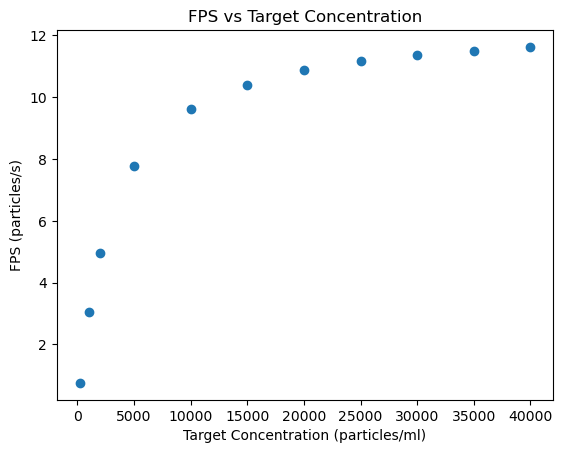

In [70]:
summary_df[["FPS","Target_concentration","Concentration_estimate"]].tail(5)
plt.scatter(summary_df["Target_concentration"], summary_df["FPS"])
plt.xlabel("Target Concentration (particles/ml)")
plt.ylabel("FPS (particles/s)")
plt.title("FPS vs Target Concentration")
plt.show()


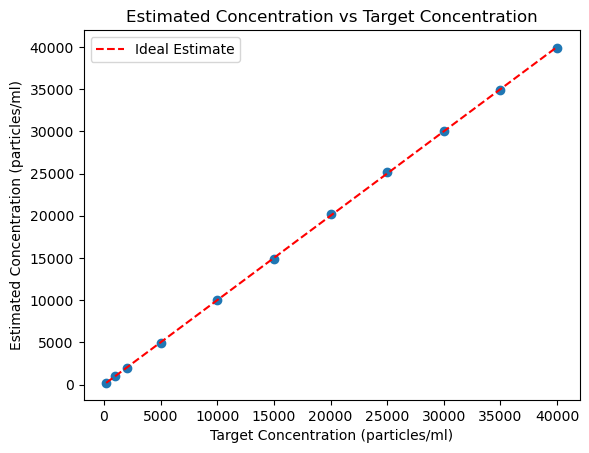

In [73]:
plt.scatter(summary_df["Target_concentration"], summary_df["Concentration_estimate"])
plt.plot(summary_df["Target_concentration"], summary_df["Target_concentration"], color='red', linestyle='--', label="Ideal Estimate")
plt.xlabel("Target Concentration (particles/ml)")
plt.ylabel("Estimated Concentration (particles/ml)")
plt.title("Estimated Concentration vs Target Concentration")
plt.legend()
plt.show()

## This is all with uniform poisson distrib what if I use a skewed distrib still modeled using beta distrib now
see this link for examples of the beta distribution : ![alt text](https://towardsdatascience.com/wp-content/uploads/2023/10/1-R7czN-vorNob8l74xJMmg.png)

In [74]:
import numpy as np
import pandas as pd

def simulate_skewed_particles(
    mean_particles,
    run_duration=1200,
    beta_a=1,
    beta_b=3,
    seed=None
):
    rng = np.random.default_rng(seed)

    n_particles = rng.poisson(mean_particles)

    runtime_fraction = rng.beta(
        beta_a,
        beta_b,
        size=n_particles
    )

    arrival_times = np.sort(runtime_fraction * run_duration)

    return pd.DataFrame({
        "arrival_time": arrival_times,
        "runtime_fraction": arrival_times / run_duration
    })

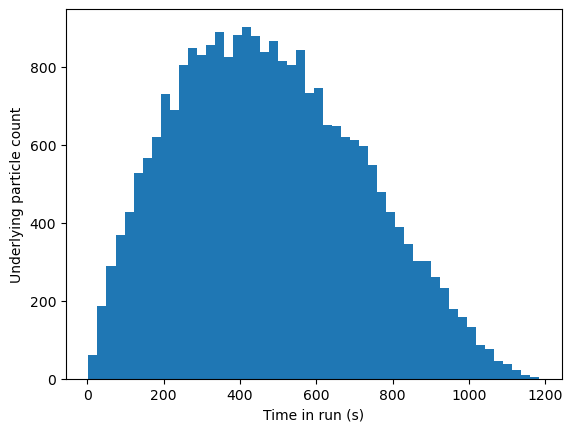

In [92]:
early_skew_df = simulate_skewed_particles(
    mean_particles=25000,
    beta_a=2,
    beta_b=3,
    run_duration=1200,
    seed=1
)

plt.hist(early_skew_df["arrival_time"], bins=50)
plt.xlabel("Time in run (s)")
plt.ylabel("Underlying particle count")
plt.show()

### Now repeat with this skewed set

   target_particles  underlying_particles  sampled_particles  \
0              1000                  1001                894   
1              5000                  5002               3179   
2             10000                 10003               4747   
3             25000                 25005               6897   
4             50000                 50007               8413   
5             75000                 75009               9188   
6            100000                100010               9667   

   rejected_particles  Volume_analyzed       FPS  Target_concentration  \
0                 107         4.702000  0.745000                 200.0   
1                1823         3.940333  2.649167                1000.0   
2                5256         3.417667  3.955833                2000.0   
3               18108         2.701000  5.747500                5000.0   
4               41594         2.195667  7.010833               10000.0   
5               65821         1.937333  7.6

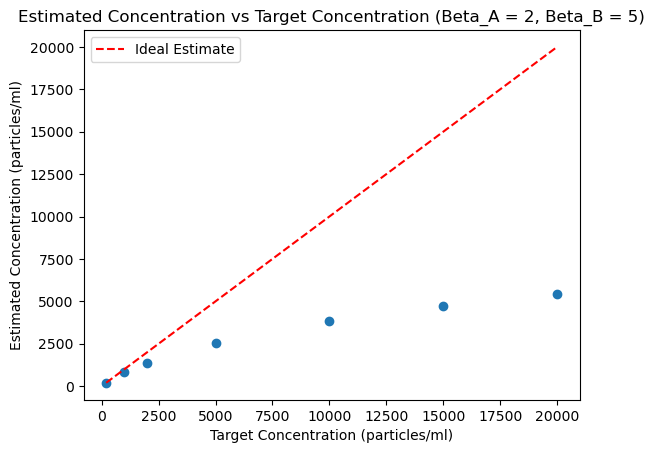

In [ ]:
import pandas as pd

particles = [1000, 5000, 10000, 25000, 50000, 75000, 100000]

summary_rows = []

for p in particles:

    times = simulate_skewed_particles(mean_particles=p,
                                       beta_a=2,
                                       beta_b=5,
                                       run_duration=1200,
                                       seed=1)

    
    ifcb_df = simulate_ifcb_sampling(
        times["arrival_time"],
        inhibit_time=0.08
    )

    underlying_particles = len(ifcb_df)
    sampled_particles = int(ifcb_df["sampled"].sum())
    rejected_particles = int((~ifcb_df["sampled"]).sum())

    Volume_analyzed = (1200 - sampled_particles * 0.08) / 240
    FPS = sampled_particles / 1200
    conc_estimate = sampled_particles / Volume_analyzed

    summary_rows.append({
        "target_particles": p,
        "underlying_particles": underlying_particles,
        "sampled_particles": sampled_particles,
        "rejected_particles": rejected_particles,
        "Volume_analyzed": Volume_analyzed,
        "FPS": FPS,
        "Target_concentration": p / 5, ## Assuming 5ml syringe
        "Concentration_estimate": conc_estimate
    })

summary_df = pd.DataFrame(summary_rows)

print(summary_df)
plt.scatter(summary_df["Target_concentration"], summary_df["Concentration_estimate"])
plt.plot(summary_df["Target_concentration"], summary_df["Target_concentration"], color='red', linestyle='--', label="Ideal Estimate")
plt.xlabel("Target Concentration (particles/ml)")
plt.ylabel("Estimated Concentration (particles/ml)")
plt.title("Estimated Concentration vs Target Concentration (Beta_A = 2, Beta_B = 5)")
plt.legend()
plt.show()

## Now that we have this workflow can i use existing data in a similar way to build an underlying distribution most ideal synthetic data

In [116]:
from pathlib import Path
import pandas as pd

# -----------------------------
# User inputs
# -----------------------------
data_dir = Path("/Users/michaelstaiger/Desktop/gitRepos/IFCBParticleSize/EmpyricalAnalysis/IFCBData/SeaTrac/subsampled/radbot_ios/merged")
file_pattern = "*.csv"


# -----------------------------
# Compile filtered data
# -----------------------------
compiled_dfs = []

for file in data_dir.glob(file_pattern):
    df = pd.read_csv(file)
    df["source_file"] = file.name

    compiled_dfs.append(df)

if compiled_dfs:
    compiled_df = pd.concat(compiled_dfs, ignore_index=True)
else:
    compiled_df = pd.DataFrame()

print(f"Compiled dataframe shape: {compiled_df.shape}")
emp_times = compiled_df["RunTime"].values

Compiled dataframe shape: (34719, 158)


In [ ]:


def sample_empirical_particles(
    runtime_array,
    mean_particles,
    replace=False,
    seed=None
):
    rng = np.random.default_rng(seed)

    runtime_array = np.asarray(runtime_array)
    n_particles = rng.poisson(mean_particles)

    sampled_runtime = rng.choice(
        runtime_array,
        size=n_particles,
        replace=replace
    )

    arrival_times = np.sort(sampled_runtime)

    return pd.DataFrame({
        "arrival_time": arrival_times
    })



In [ ]:
sample_df = sample_empirical_particles(
    runtime_array=emp_times,
    mean_particles=25000,
    replace=False,
    seed=1
)

ifcb_df = simulate_ifcb_sampling(
    sample_df["arrival_time"],
    inhibit_time=0.08
)

    target_particles  underlying_particles  sampled_particles  \
0               1000                  1001                910   
1               5000                  5002               3413   
2              10000                 10003               5200   
3              25000                 25005               7704   
4              50000                 50007               9153   
5              75000                 75009               9617   
6             100000                100010               9824   
7             125000                125012               9907   
8             150000                150013               9946   
9             175000                175014               9970   
10            200000                200015               9977   

    rejected_particles  Volume_analyzed       FPS  Target_concentration  \
0                   91         4.696667  0.758333                 200.0   
1                 1589         3.862333  2.844167                1000

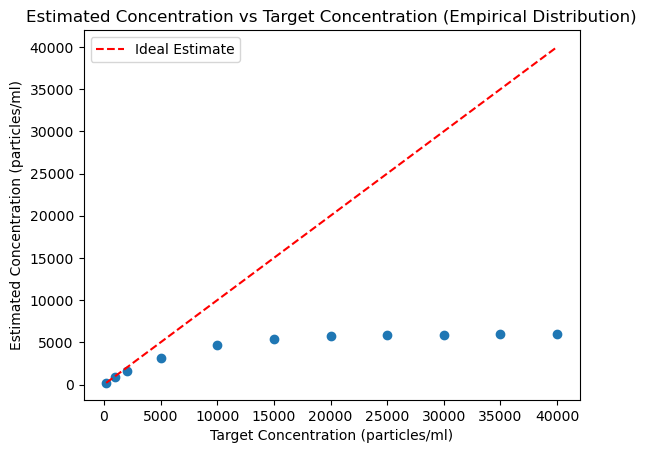

In [119]:
import pandas as pd

particles = [1000, 5000, 10000, 25000, 50000, 75000, 100000, 125000, 150000, 175000, 200000]

summary_rows = []

for p in particles:

    times = sample_empirical_particles(mean_particles=p,
                                       runtime_array=emp_times,
                                       replace=True,
                                       seed=1)

    
    ifcb_df = simulate_ifcb_sampling(
        times["arrival_time"],
        inhibit_time=0.08
    )

    underlying_particles = len(ifcb_df)
    sampled_particles = int(ifcb_df["sampled"].sum())
    rejected_particles = int((~ifcb_df["sampled"]).sum())

    Volume_analyzed = (1200 - sampled_particles * 0.08) / 240
    FPS = sampled_particles / 1200
    conc_estimate = sampled_particles / Volume_analyzed

    summary_rows.append({
        "target_particles": p,
        "underlying_particles": underlying_particles,
        "sampled_particles": sampled_particles,
        "rejected_particles": rejected_particles,
        "Volume_analyzed": Volume_analyzed,
        "FPS": FPS,
        "Target_concentration": p / 5, ## Assuming 5ml syringe
        "Concentration_estimate": conc_estimate
    })

summary_df = pd.DataFrame(summary_rows)

print(summary_df)
plt.scatter(summary_df["Target_concentration"], summary_df["Concentration_estimate"])
plt.plot(summary_df["Target_concentration"], summary_df["Target_concentration"], color='red', linestyle='--', label="Ideal Estimate")
plt.xlabel("Target Concentration (particles/ml)")
plt.ylabel("Estimated Concentration (particles/ml)")
plt.title("Estimated Concentration vs Target Concentration (Empirical Distribution)")
plt.legend()
plt.show()